In [2]:
## importing all necessary librabries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from xgboost import XGBRegressor

In [3]:
##reading weather data
file_path = "/home/home/code/xucenying/grid-intelligence/notebooks/susanta/Energy_price vs weather data/germany_weather.csv"
weather_df=pd.read_csv(file_path)

In [4]:
weather_df.head(5)

,city,latitude,longitude,timestamp,temperature_c,humidity_percent,cloud_cover_percent,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2
0,Berlin,52.52,13.41,2014-01-01T00:00,-0.3,94,24,0.0,0.0,0.0
1,Berlin,52.52,13.41,2014-01-01T01:00,-0.3,94,53,0.0,0.0,0.0
2,Berlin,52.52,13.41,2014-01-01T02:00,-0.3,94,82,0.0,0.0,0.0
3,Berlin,52.52,13.41,2014-01-01T03:00,-0.2,94,82,0.0,0.0,0.0
4,Berlin,52.52,13.41,2014-01-01T04:00,-0.1,94,97,0.0,0.0,0.0


In [5]:
weather_df.keys()

Index(['city', 'latitude', 'longitude', 'timestamp', 'temperature_c',
       'humidity_percent', 'cloud_cover_percent', 'shortwave_radiation_wm2',
       'direct_radiation_wm2', 'diffuse_radiation_wm2'],
      dtype='object')

In [6]:
### 'shortwave_radiation_wm2' ='direct_radiation_wm2'+ 'diffuse_radiation_wm2'

weather_germany_df = weather_df.drop(columns = ["direct_radiation_wm2","diffuse_radiation_wm2", "latitude","longitude"])
weather_germany_df.head()

,city,timestamp,temperature_c,humidity_percent,cloud_cover_percent,shortwave_radiation_wm2
0,Berlin,2014-01-01T00:00,-0.3,94,24,0.0
1,Berlin,2014-01-01T01:00,-0.3,94,53,0.0
2,Berlin,2014-01-01T02:00,-0.3,94,82,0.0
3,Berlin,2014-01-01T03:00,-0.2,94,82,0.0
4,Berlin,2014-01-01T04:00,-0.1,94,97,0.0


In [7]:
weather_avg = weather_germany_df.groupby("timestamp").agg({
    "temperature_c": "mean",
    "humidity_percent": "mean",
    "cloud_cover_percent": "mean",
    "shortwave_radiation_wm2": "mean"
}).reset_index()

In [8]:
weather_avg.head()

,timestamp,temperature_c,humidity_percent,cloud_cover_percent,shortwave_radiation_wm2
0,2014-01-01T00:00,0.800,78.75,80.75,0.0
1,2014-01-01T01:00,0.825,78.00,84.75,0.0
2,2014-01-01T02:00,0.825,78.25,91.50,0.0
3,2014-01-01T03:00,0.750,81.75,85.00,0.0
4,2014-01-01T04:00,0.675,84.50,92.75,0.0


In [9]:
# Convert to datetime
weather_avg["DateTime(UTC)"] = pd.to_datetime(weather_avg["timestamp"])
weather_avg = weather_avg.drop(columns=["timestamp"])


In [10]:
weather_avg.head()

,temperature_c,humidity_percent,cloud_cover_percent,shortwave_radiation_wm2,DateTime(UTC)
0,0.800,78.75,80.75,0.0,2014-01-01 00:00:00
1,0.825,78.00,84.75,0.0,2014-01-01 01:00:00
2,0.825,78.25,91.50,0.0,2014-01-01 02:00:00
3,0.750,81.75,85.00,0.0,2014-01-01 03:00:00
4,0.675,84.50,92.75,0.0,2014-01-01 04:00:00


In [11]:
weather_avg.to_csv("weather_avg.csv", index=False, date_format="%Y-%m-%d %H:%M:%S")

In [12]:
pwd


'/home/home/code/xucenying/grid-intelligence/notebooks/susanta'

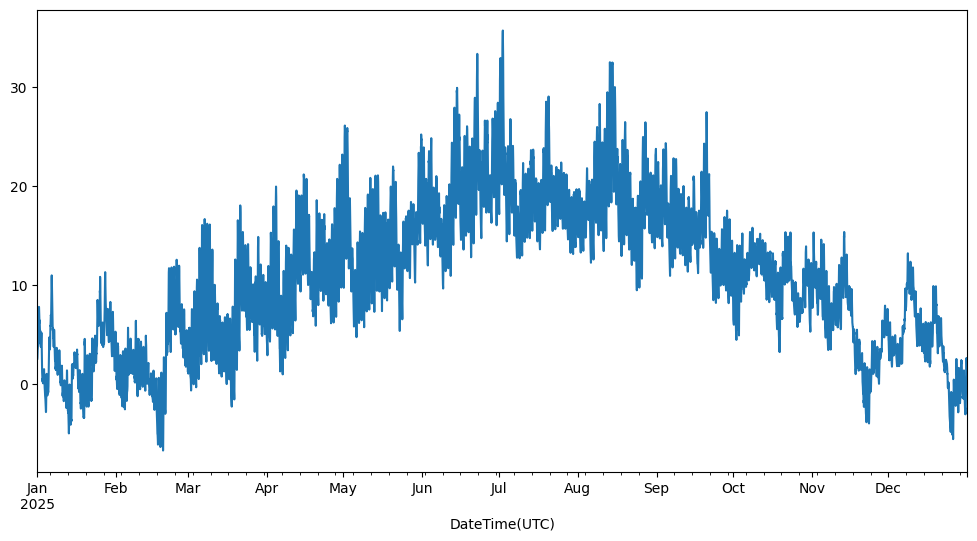

In [13]:
# Filter by year
weather_2025 = weather_avg[weather_avg["DateTime(UTC)"].dt.year == 2025]

# Plot
weather_2025.set_index("DateTime(UTC)")["temperature_c"].plot(figsize=(12,6))
plt.show()

In [14]:
##reading combined csv files for energy_price
file_path_energy = "/home/home/code/xucenying/grid-intelligence/notebooks/susanta/Energy_price vs weather data/combined_energy_price_cleaned.csv"
energy_df = pd.read_csv(file_path_energy, sep="\t")

/tmp/ipykernel_108609/2191306532.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  energy_df = pd.read_csv(file_path_energy, sep="\t")


In [15]:
energy_df.tail(5)

,InstanceCode,DateTime(UTC),ResolutionCode,AreaDisplayName,Sequence,Price[Currency/MWh],UpdateTime(UTC)
378302,36144fcdf23ed261e907606cc997fbe5,2026-04-21 20:45:00,PT15M,DE-LU,2,114.16,2026-04-20 09:06:09
378303,36144fcdf23ed261e907606cc997fbe5,2026-04-21 21:00:00,PT15M,DE-LU,2,120.27,2026-04-20 09:06:09
378304,36144fcdf23ed261e907606cc997fbe5,2026-04-21 21:15:00,PT15M,DE-LU,2,117.33,2026-04-20 09:06:09
378305,36144fcdf23ed261e907606cc997fbe5,2026-04-21 21:30:00,PT15M,DE-LU,2,112.15,2026-04-20 09:06:09
378306,36144fcdf23ed261e907606cc997fbe5,2026-04-21 21:45:00,PT15M,DE-LU,2,106.96,2026-04-20 09:06:09


In [16]:
energy_df.shape


(378307, 7)

In [17]:
energy_df.keys()

Index(['InstanceCode', 'DateTime(UTC)', 'ResolutionCode', 'AreaDisplayName',
       'Sequence', 'Price[Currency/MWh]', 'UpdateTime(UTC)'],
      dtype='object')

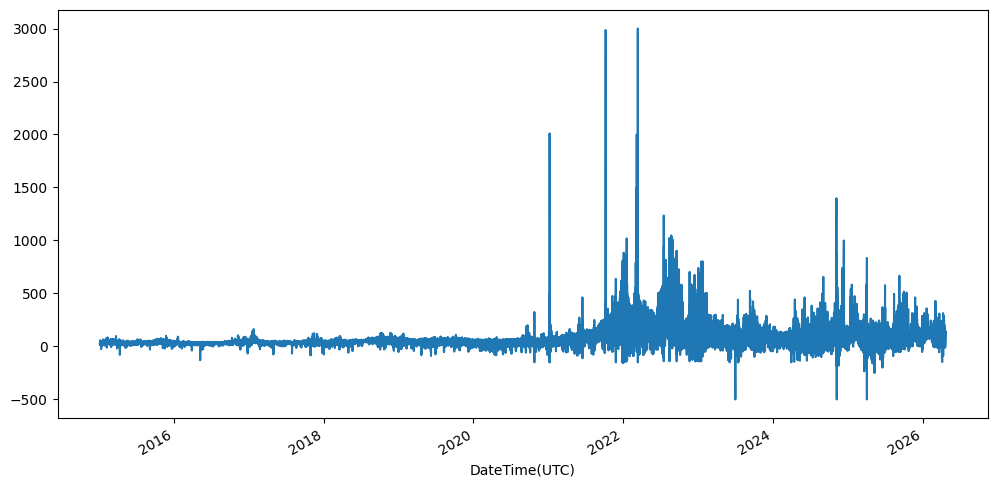

In [18]:
energy_df["DateTime(UTC)"] = pd.to_datetime(energy_df["DateTime(UTC)"])
energy_df.set_index("DateTime(UTC)")["Price[Currency/MWh]"].plot(figsize=(12,6))
plt.show()

In [19]:
energy_df["DateTime(UTC)"]

0        2015-01-04 23:00:00
1        2015-01-05 00:00:00
2        2015-01-05 01:00:00
3        2015-01-05 02:00:00
4        2015-01-05 03:00:00
                 ...        
378302   2026-04-21 20:45:00
378303   2026-04-21 21:00:00
378304   2026-04-21 21:15:00
378305   2026-04-21 21:30:00
378306   2026-04-21 21:45:00
Name: DateTime(UTC), Length: 378307, dtype: datetime64[ns]

In [20]:
type(energy_df["DateTime(UTC)"])

pandas.core.series.Series

In [21]:
df_2025 = energy_df[energy_df["DateTime(UTC)"].dt.year == 2025]
df_2025.tail()

,InstanceCode,DateTime(UTC),ResolutionCode,AreaDisplayName,Sequence,Price[Currency/MWh],UpdateTime(UTC)
357174,e0eec9f40632e9a66634803a4572a2e2,2025-12-31 23:15:00,PT15M,DE-LU,1,61.48,2025-12-31 12:55:08
357175,8e2819009ba367acae485984e26d25bf,2025-12-31 23:30:00,PT15M,DE-LU,2,63.00,2025-12-30 10:07:37
357176,e0eec9f40632e9a66634803a4572a2e2,2025-12-31 23:30:00,PT15M,DE-LU,1,58.00,2025-12-31 12:55:08
357177,8e2819009ba367acae485984e26d25bf,2025-12-31 23:45:00,PT15M,DE-LU,2,41.08,2025-12-30 10:07:37
357178,e0eec9f40632e9a66634803a4572a2e2,2025-12-31 23:45:00,PT15M,DE-LU,1,49.99,2025-12-31 12:55:08


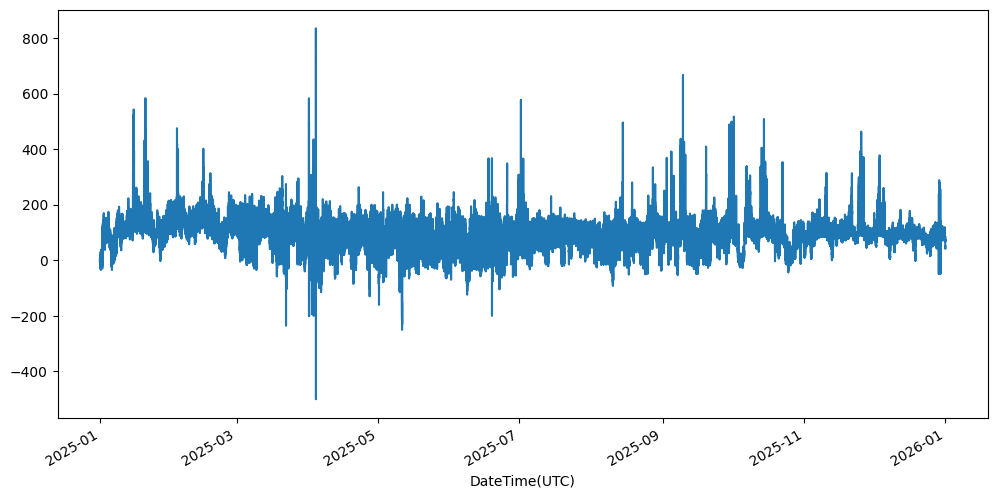

In [22]:
df_2025 = energy_df[energy_df["DateTime(UTC)"].dt.year == 2025]
df_2025.set_index("DateTime(UTC)")["Price[Currency/MWh]"].plot(figsize=(12,6))
plt.show()

In [23]:
year_list = np.arange(2015, 2027, 1)
year_list

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025,
       2026])

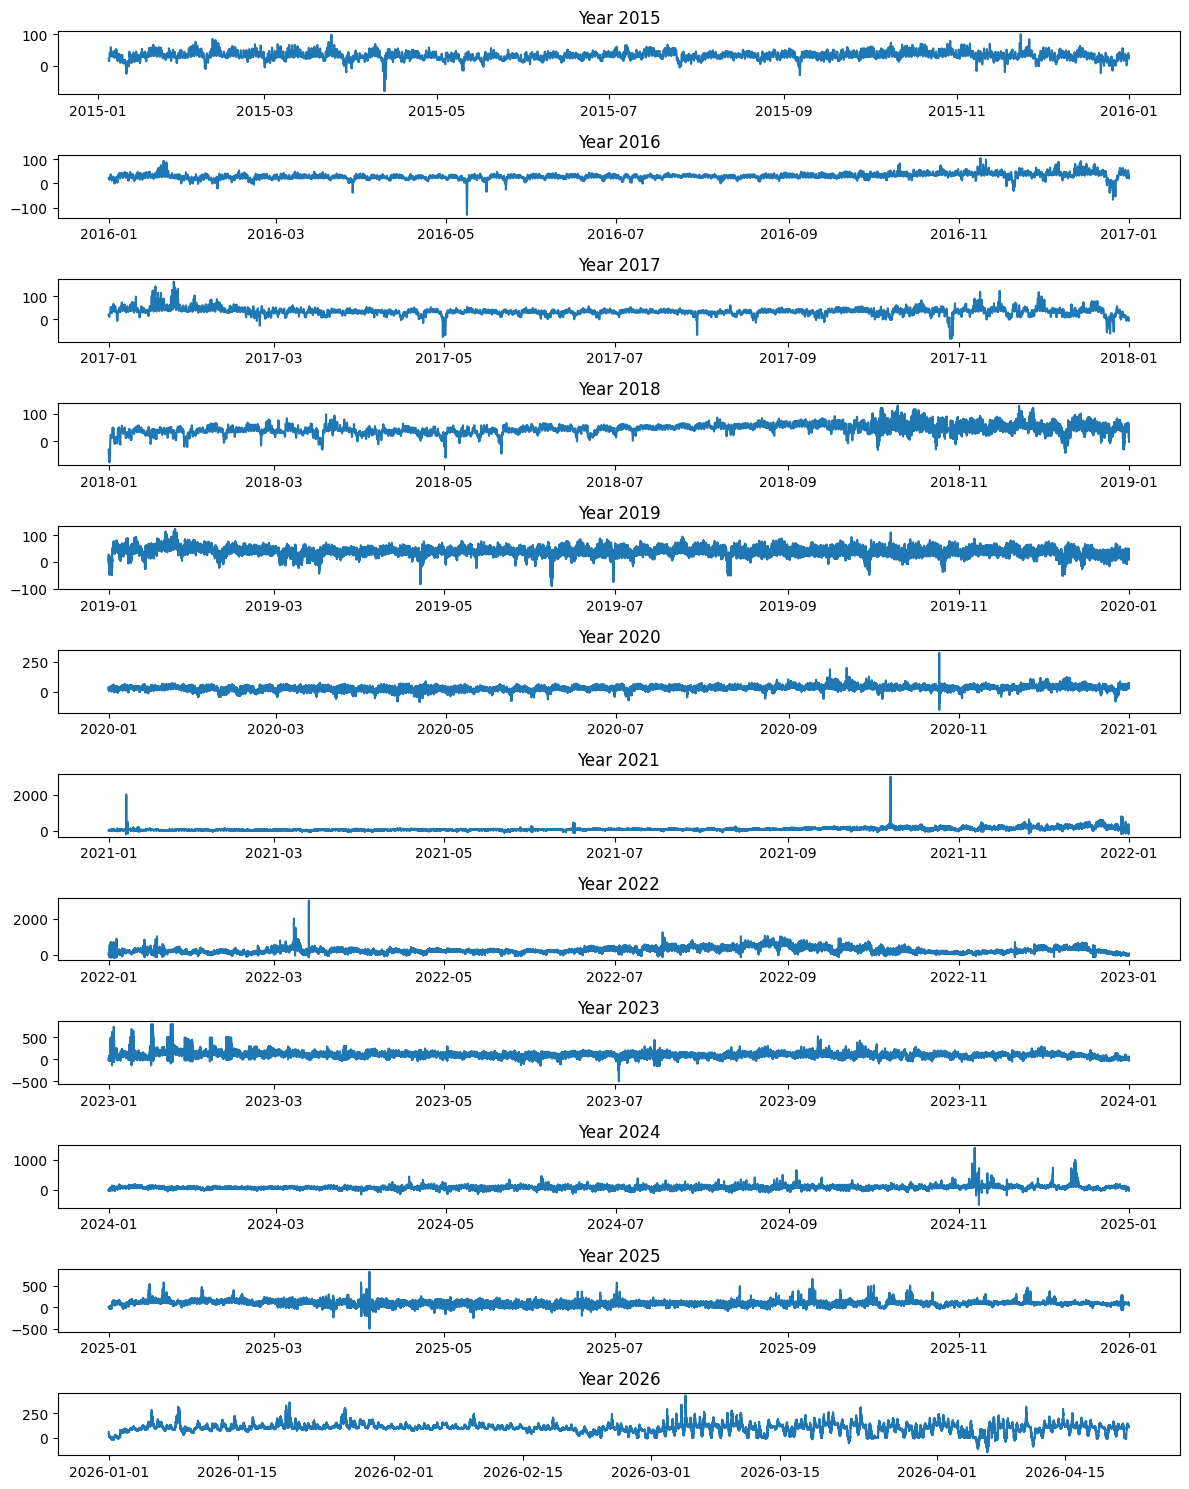

In [24]:
plt.figure(figsize=(12,15))

for idx, year in enumerate(year_list, 1):
    df_i = energy_df[energy_df["DateTime(UTC)"].dt.year == year]

    plt.subplot(len(year_list), 1, idx)
    plt.plot(df_i["DateTime(UTC)"], df_i["Price[Currency/MWh]"])
    plt.title(f"Year {year}")


plt.tight_layout()
plt.show()

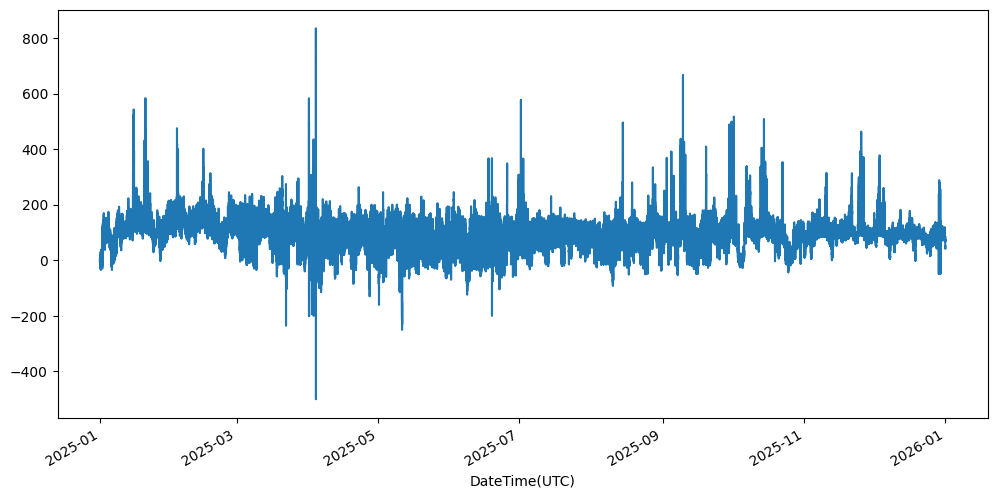

In [25]:
energy_df_2025 = energy_df[energy_df["DateTime(UTC)"].dt.year == 2025]
energy_df_2025.set_index("DateTime(UTC)")["Price[Currency/MWh]"].plot(figsize=(12,6))
plt.show()

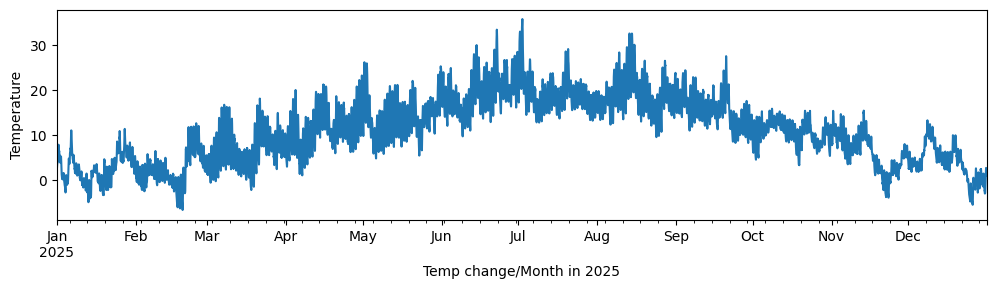

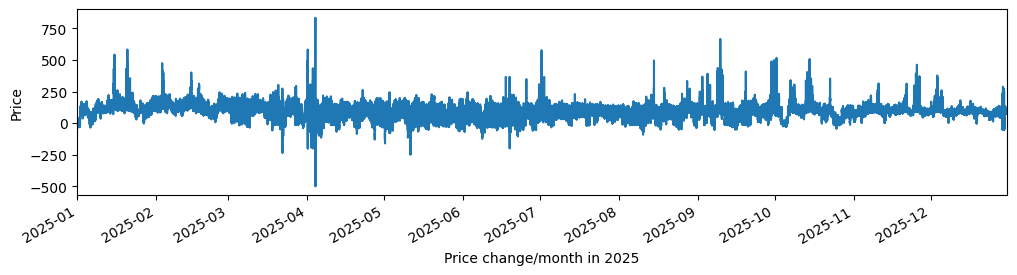

In [26]:
###temperature vs energy comparison plots
plt.subplot(2,1,1)
weather_2025.set_index("DateTime(UTC)")["temperature_c"].plot(figsize=(12,6))
plt.xlabel("Temp change/Month in 2025")
plt.ylabel("Temperature")
plt.show()

plt.subplot(2,1,2)
energy_df_2025.set_index("DateTime(UTC)")["Price[Currency/MWh]"].plot(figsize=(12,6))
plt.xlabel("Price change/month in 2025")
plt.ylabel("Price")
plt.xlim(pd.to_datetime("2025-01-01"), pd.to_datetime("2025-12-31"))
plt.show()

In [27]:
df_merged_weather_price = pd.merge(
    energy_df,
    weather_avg,
    on="DateTime(UTC)",
    how="inner"
)

In [28]:
df_merged_weather_price.keys()

Index(['InstanceCode', 'DateTime(UTC)', 'ResolutionCode', 'AreaDisplayName',
       'Sequence', 'Price[Currency/MWh]', 'UpdateTime(UTC)', 'temperature_c',
       'humidity_percent', 'cloud_cover_percent', 'shortwave_radiation_wm2'],
      dtype='object')

In [29]:
df_merged = df_merged_weather_price.sample(n=5000, random_state=42)

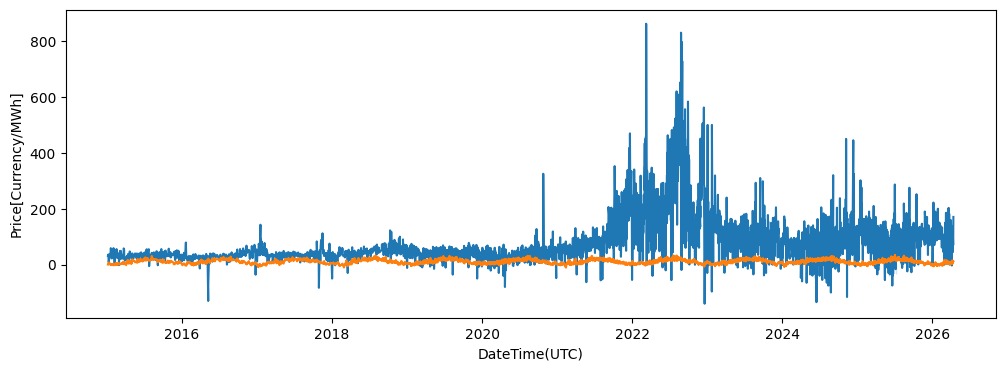

In [30]:
plt.figure(figsize=(12,4))
sns.lineplot(x="DateTime(UTC)", y="Price[Currency/MWh]", data=df_merged)
sns.lineplot(x="DateTime(UTC)", y="temperature_c", data=df_merged)

plt.show()

<Axes: xlabel='DateTime(UTC)', ylabel='Price[Currency/MWh]'>

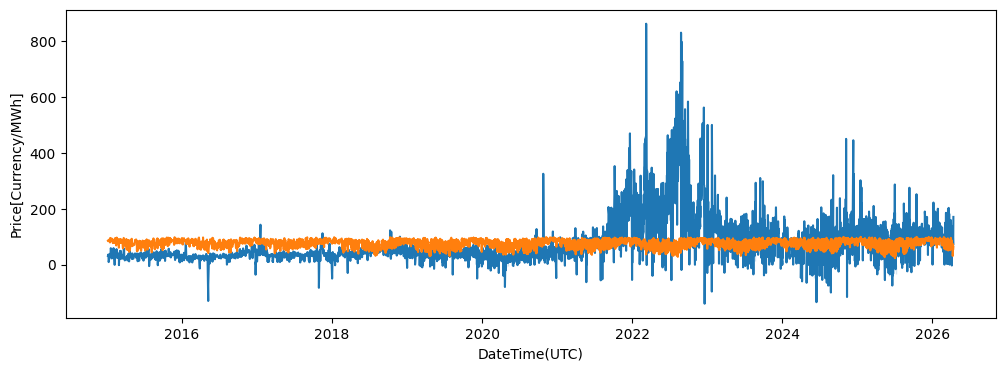

In [31]:
plt.figure(figsize=(12,4))
sns.lineplot(x="DateTime(UTC)", y="Price[Currency/MWh]", data=df_merged)
sns.lineplot(x="DateTime(UTC)", y="humidity_percent", data=df_merged)


<Axes: xlabel='DateTime(UTC)', ylabel='Price[Currency/MWh]'>

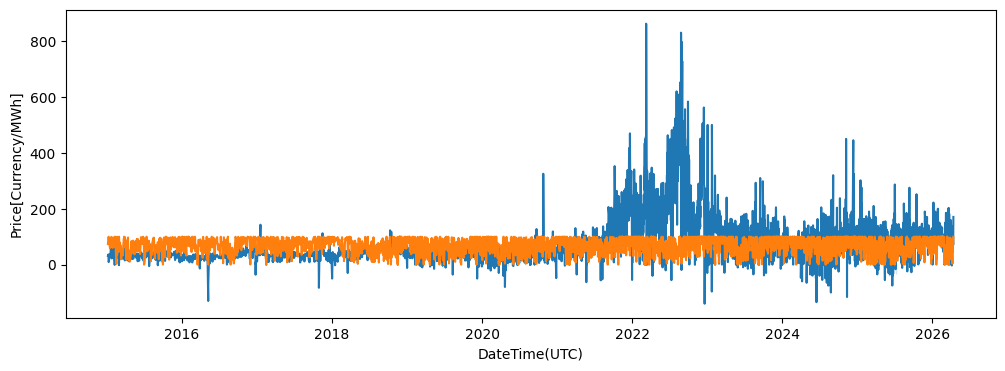

In [32]:
plt.figure(figsize=(12,4))
sns.lineplot(x="DateTime(UTC)", y="Price[Currency/MWh]", data=df_merged)
sns.lineplot(x="DateTime(UTC)", y="cloud_cover_percent", data=df_merged)


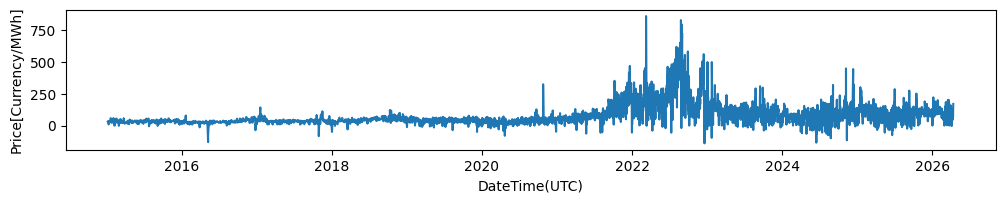

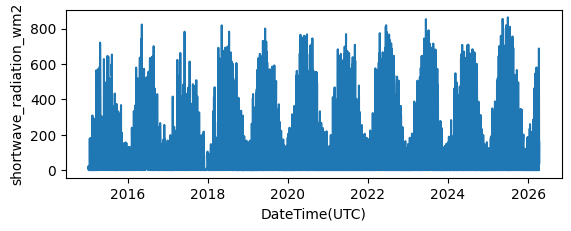

In [33]:
plt.figure(figsize=(12,4))

plt.subplot(2,1,1)
sns.lineplot(x="DateTime(UTC)", y="Price[Currency/MWh]", data=df_merged)
plt.show()

plt.subplot(2,1,2)
sns.lineplot(x="DateTime(UTC)", y="shortwave_radiation_wm2", data=df_merged)
plt.show()

In [34]:
df_merged_weather_price.isnull().sum()

InstanceCode               0
DateTime(UTC)              0
ResolutionCode             0
AreaDisplayName            0
Sequence                   0
Price[Currency/MWh]        0
UpdateTime(UTC)            0
temperature_c              0
humidity_percent           0
cloud_cover_percent        0
shortwave_radiation_wm2    0
dtype: int64

In [35]:
corr = df_merged_weather_price[['Price[Currency/MWh]', 'temperature_c', 'humidity_percent', 'cloud_cover_percent', 'shortwave_radiation_wm2']].corr()
print(corr)

                         Price[Currency/MWh]  temperature_c  humidity_percent  \
Price[Currency/MWh]                 1.000000      -0.011680          0.038927   
temperature_c                      -0.011680       1.000000         -0.592915   
humidity_percent                    0.038927      -0.592915          1.000000   
cloud_cover_percent                 0.006744      -0.155706          0.247162   
shortwave_radiation_wm2            -0.084359       0.558397         -0.755941   

                         cloud_cover_percent  shortwave_radiation_wm2  
Price[Currency/MWh]                 0.006744                -0.084359  
temperature_c                      -0.155706                 0.558397  
humidity_percent                    0.247162                -0.755941  
cloud_cover_percent                 1.000000                -0.124040  
shortwave_radiation_wm2            -0.124040                 1.000000  


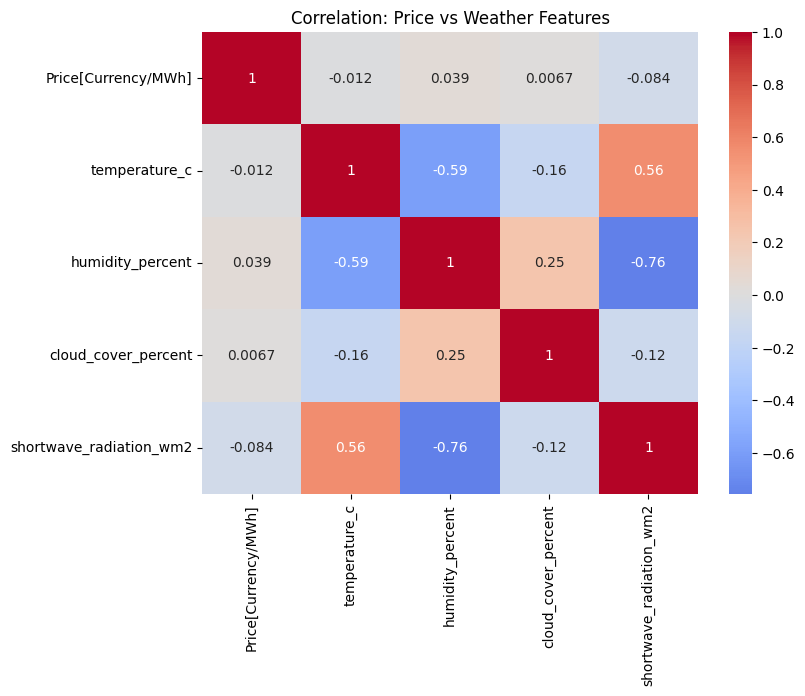

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation: Price vs Weather Features")
plt.show()

***Modelling with xgboost to get feature importance***

In [37]:
energy_df = energy_df.sort_values("DateTime(UTC)")

energy_df["diff"] = energy_df["DateTime(UTC)"].diff()

print(energy_df["diff"].value_counts())

diff
0 days 00:15:00    264859
0 days 00:00:00     80663
0 days 01:00:00     32784
Name: count, dtype: int64


In [38]:
##splitting 1 hr intervals into 15 mins intervals and filling with same values
df_15min = energy_df[energy_df["diff"] == pd.Timedelta("15min")]
df_1h = energy_df[energy_df["diff"] == pd.Timedelta("1h")]

df_1h = df_1h.set_index("DateTime(UTC)")

df_1h_15min = df_1h.resample("15min").ffill()

In [39]:
df_final = pd.concat([df_15min, df_1h_15min])

In [40]:
df_final = df_final[df_final["Sequence"]==2]

In [41]:
df_final.head()

,InstanceCode,DateTime(UTC),ResolutionCode,AreaDisplayName,Sequence,Price[Currency/MWh],UpdateTime(UTC),diff
131072,4f19569337a13b2731963d9745874e91,2020-12-29 00:30:00,PT15M,DE-LU,2,35.23,2024-10-03 13:34:43,0 days 00:15:00
131073,4f19569337a13b2731963d9745874e91,2020-12-29 00:45:00,PT15M,DE-LU,2,29.68,2024-10-03 13:34:43,0 days 00:15:00
131074,4f19569337a13b2731963d9745874e91,2020-12-29 01:00:00,PT15M,DE-LU,2,42.18,2024-10-03 13:34:43,0 days 00:15:00
131076,4f19569337a13b2731963d9745874e91,2020-12-29 01:15:00,PT15M,DE-LU,2,36.62,2024-10-03 13:34:43,0 days 00:15:00
131077,4f19569337a13b2731963d9745874e91,2020-12-29 01:30:00,PT15M,DE-LU,2,33.07,2024-10-03 13:34:43,0 days 00:15:00


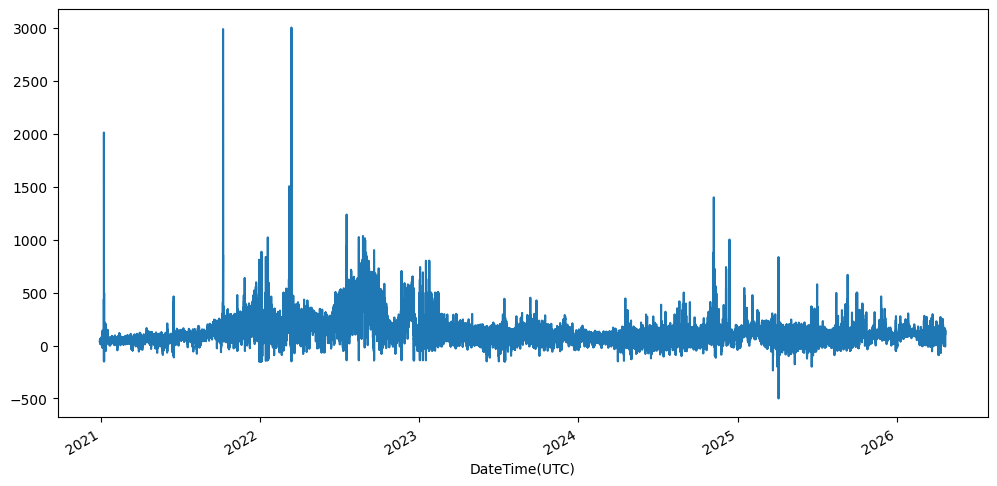

In [42]:
df_final.set_index("DateTime(UTC)")["Price[Currency/MWh]"].plot(figsize=(12,6))
plt.show()

In [43]:
df_merged_final = pd.merge(
    df_final,
    weather_avg,
    on="DateTime(UTC)",
    how="inner"
)

In [44]:
corr_2 = df_merged_final[['Price[Currency/MWh]', 'temperature_c', 'humidity_percent', 'cloud_cover_percent', 'shortwave_radiation_wm2']].corr()

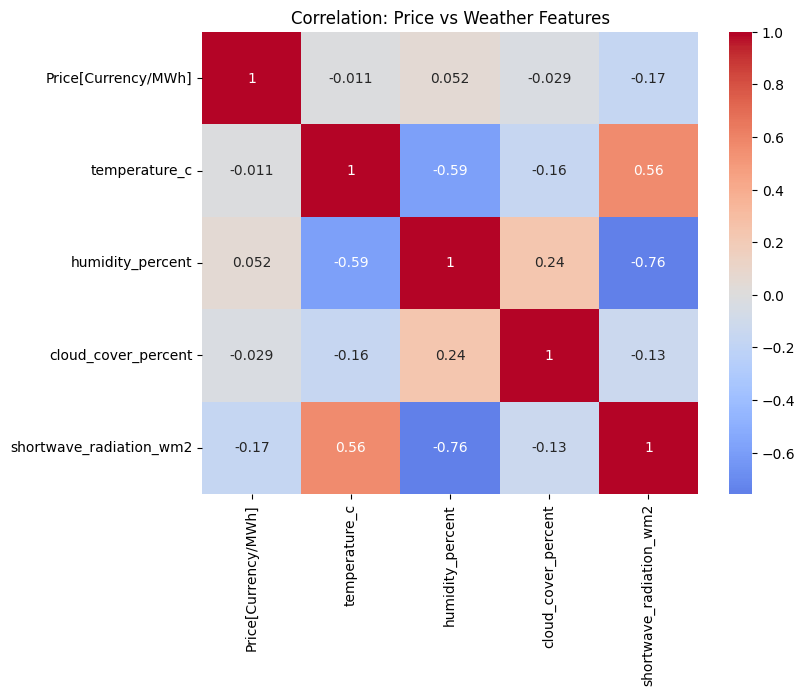

In [45]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_2, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation: Price vs Weather Features")
plt.show()

In [46]:
for lag in [1,4,8,24,96,192,672]:
    df_merged_final[f"price_lag_{lag}"] = df_merged_final["Price[Currency/MWh]"].shift(lag)

In [47]:
features = [
    "temperature_c",
    "humidity_percent",
    "cloud_cover_percent",
    "shortwave_radiation_wm2"
]

target = "Price[Currency/MWh]"


X = df_merged_final[features]
y = df_merged_final[target]

In [53]:
df_merged_final.head()

,InstanceCode,DateTime(UTC),ResolutionCode,AreaDisplayName,Sequence,Price[Currency/MWh],UpdateTime(UTC),diff,temperature_c,humidity_percent,cloud_cover_percent,shortwave_radiation_wm2,price_lag_1,price_lag_4,price_lag_8,price_lag_24,price_lag_96,price_lag_192,price_lag_672
0,4f19569337a13b2731963d9745874e91,2020-12-29 01:00:00,PT15M,DE-LU,2,42.18,2024-10-03 13:34:43,0 days 00:15:00,0.200,92.50,83.25,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4f19569337a13b2731963d9745874e91,2020-12-29 02:00:00,PT15M,DE-LU,2,36.09,2024-10-03 13:34:43,0 days 00:15:00,0.575,93.50,80.50,0.0,42.18,NaN,NaN,NaN,NaN,NaN,NaN
2,4f19569337a13b2731963d9745874e91,2020-12-29 03:00:00,PT15M,DE-LU,2,31.21,2024-10-03 13:34:43,0 days 00:15:00,0.900,92.75,97.75,0.0,36.09,NaN,NaN,NaN,NaN,NaN,NaN
3,4f19569337a13b2731963d9745874e91,2020-12-29 06:00:00,PT15M,DE-LU,2,35.40,2024-10-03 13:34:43,0 days 00:15:00,0.600,93.75,92.50,0.0,31.21,NaN,NaN,NaN,NaN,NaN,NaN
4,4f19569337a13b2731963d9745874e91,2020-12-29 11:00:00,PT15M,DE-LU,2,56.55,2024-10-03 13:34:43,0 days 00:15:00,1.625,86.50,84.25,60.5,35.40,42.18,NaN,NaN,NaN,NaN,NaN


In [55]:
df_merged_final.to_csv("data_energy_weather_lag.csv", index=False)

In [2]:
import pandas as pd
data = pd.read_csv("data_energy_weather_lag.csv")
data.head()

,InstanceCode,DateTime(UTC),ResolutionCode,AreaDisplayName,Sequence,Price[Currency/MWh],UpdateTime(UTC),diff,temperature_c,humidity_percent,cloud_cover_percent,shortwave_radiation_wm2,price_lag_1,price_lag_4,price_lag_8,price_lag_24,price_lag_96,price_lag_192,price_lag_672
0,4f19569337a13b2731963d9745874e91,2020-12-29 01:00:00,PT15M,DE-LU,2,42.18,2024-10-03 13:34:43,0 days 00:15:00,0.200,92.50,83.25,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4f19569337a13b2731963d9745874e91,2020-12-29 02:00:00,PT15M,DE-LU,2,36.09,2024-10-03 13:34:43,0 days 00:15:00,0.575,93.50,80.50,0.0,42.18,NaN,NaN,NaN,NaN,NaN,NaN
2,4f19569337a13b2731963d9745874e91,2020-12-29 03:00:00,PT15M,DE-LU,2,31.21,2024-10-03 13:34:43,0 days 00:15:00,0.900,92.75,97.75,0.0,36.09,NaN,NaN,NaN,NaN,NaN,NaN
3,4f19569337a13b2731963d9745874e91,2020-12-29 06:00:00,PT15M,DE-LU,2,35.40,2024-10-03 13:34:43,0 days 00:15:00,0.600,93.75,92.50,0.0,31.21,NaN,NaN,NaN,NaN,NaN,NaN
4,4f19569337a13b2731963d9745874e91,2020-12-29 11:00:00,PT15M,DE-LU,2,56.55,2024-10-03 13:34:43,0 days 00:15:00,1.625,86.50,84.25,60.5,35.40,42.18,NaN,NaN,NaN,NaN,NaN


In [49]:
X = df_merged_final.dropna()[features + ["price_lag_1", "price_lag_4", "price_lag_8", "price_lag_24", "price_lag_96", "price_lag_192", "price_lag_672"]]
y = df_merged_final.dropna()[target]

In [ ]:
X = data_energy_weather_lag.dropna()[features + ["price_lag_1", "price_lag_4", "price_lag_8", "price_lag_24", "price_lag_96", "price_lag_192", "price_lag_672"]]
y = data_energy_weather_lag.dropna()[target]

In [ ]:
for lag in [1,4,8,24,96,192,672]:
    data_energy_weather_lag[f"price_lag_{lag}"] = data_energy_weather_lag["Price[Currency/MWh]"].shift(lag)

In [50]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=50,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [51]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

price_lag_1                0.746694
price_lag_4                0.043544
price_lag_8                0.039338
price_lag_24               0.028978
shortwave_radiation_wm2    0.028763
price_lag_96               0.023572
humidity_percent           0.022092
price_lag_672              0.019228
price_lag_192              0.017332
temperature_c              0.016536
cloud_cover_percent        0.013924
dtype: float32
